<a href="https://colab.research.google.com/github/leotamasauskas/SAC_API/blob/main/SAC_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pystac-client

In [ ]:
!pip install rasterio shapely matplotlib

In [ ]:
!pip install rasterio shapely matplotlib tqdm

In [ ]:
import pystac_client
import numpy as np
import rasterio
from rasterio.crs import CRS
from rasterio.warp import transform
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

In [ ]:
pystac_client.__version__

'0.8.3'

In [ ]:
service = pystac_client.Client.open('https://data.inpe.br/bdc/stac/v1/')

In [ ]:
bbox = (-48.0185,-1.3733,-47.8405,-1.2243)





In [ ]:
search = service.search(
    collections=["landsat-2"],
    bbox=bbox,
    datetime="2022-01-01/2022-12-31",
    query={"eo:cloud_cover": {"lt": 5}},  # Limite de cobertura de nuvens
)

items = list(search.items())
print(f"Total de itens encontrados: {len(items)}")


Total de itens encontrados: 1


In [ ]:
service.get_collection("landsat-2")

<CollectionClient id=landsat-2>

In [ ]:
# Lista para armazenar as URLs do canal lwir11
lwir11_urls = []

# Iterar sobre os itens encontrados
for item in items:
    # Verificar se o item contém o canal lwir11
    if 'lwir11' in item.assets:
        # Adicionar a URL do canal lwir11 à lista
        lwir11_urls.append(item.assets['lwir11'].href)

# Imprimir as URLs do canal lwir11 encontradas
print(f"Total de URLs lwir11 encontradas: {len(lwir11_urls)}")
for url in lwir11_urls:
    print(url)

Total de URLs lwir11 encontradas: 1
https://data.inpe.br/bdc/data/landsat/v2/223/061/2022/LC08_L2SP_223061_20220720_20220726_02_T1/LC08_L2SP_223061_20220720_20220726_02_T1_ST_B10.TIF


In [ ]:
# Selecionar o primeiro item encontrado
item = items[0]

# Exibir o ID do item e verificar as bandas disponíveis
print(f"ID do item selecionado: {item.id}")
print(f"Bandas disponíveis: {item.assets.keys()}")



ID do item selecionado: LC08_L2SP_223061_20220720_20220726_02_T1
Bandas disponíveis: dict_keys(['ang', 'red', 'blue', 'green', 'nir08', 'st_qa', 'lwir11', 'swir16', 'swir22', 'coastal', 'mtl.txt', 'mtl.xml', 'sr_stac', 'st_drad', 'st_emis', 'st_emsd', 'st_stac', 'st_trad', 'st_urad', 'mtl.json', 'qa_pixel', 'st_atran', 'st_cdist', 'qa_radsat', 'thumbnail', 'qa_aerosol', 'thumb_large.jpeg', 'thumb_small.jpeg'])


In [ ]:
def read(uri: str, bbox: list, masked: bool = True, crs: str = None):
    """Read raster window as numpy.ma.masked_array."""
    source_crs = CRS.from_string('EPSG:4326')
    if crs:
        source_crs = CRS.from_string(crs)

    # Expects the bounding box has 4 values
    w, s, e, n = bbox

    with rasterio.open(uri) as dataset:
        transformer = transform(source_crs, dataset.crs, [w, e], [s, n])
        window = from_bounds(transformer[0][0], transformer[1][0],
                             transformer[0][1], transformer[1][1], dataset.transform)
        return dataset.read(1, window=window, masked=masked)

In [ ]:
def normalize(array):
#"""Normalizes numpy arrays into scale 0.0 - 1.0"""
  array_min, array_max = array.min(), array.max()
  return ((array - array_min)/(array_max - array_min))

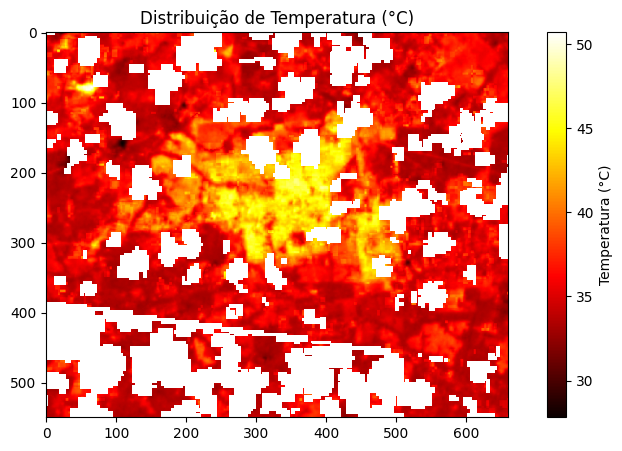

In [ ]:
lwir11 = read(items[0].assets['lwir11'].href, bbox=bbox)
scaled_lwir11 = (lwir11*0.00341802)+149
temp_celcius = scaled_lwir11 - 273


plt.figure(figsize=(10, 5))
plt.imshow(temp_celcius, cmap='hot') #, interpolation='nearest')
plt.colorbar(label='Temperatura (°C)')
plt.title('Distribuição de Temperatura (°C)')
plt.show()


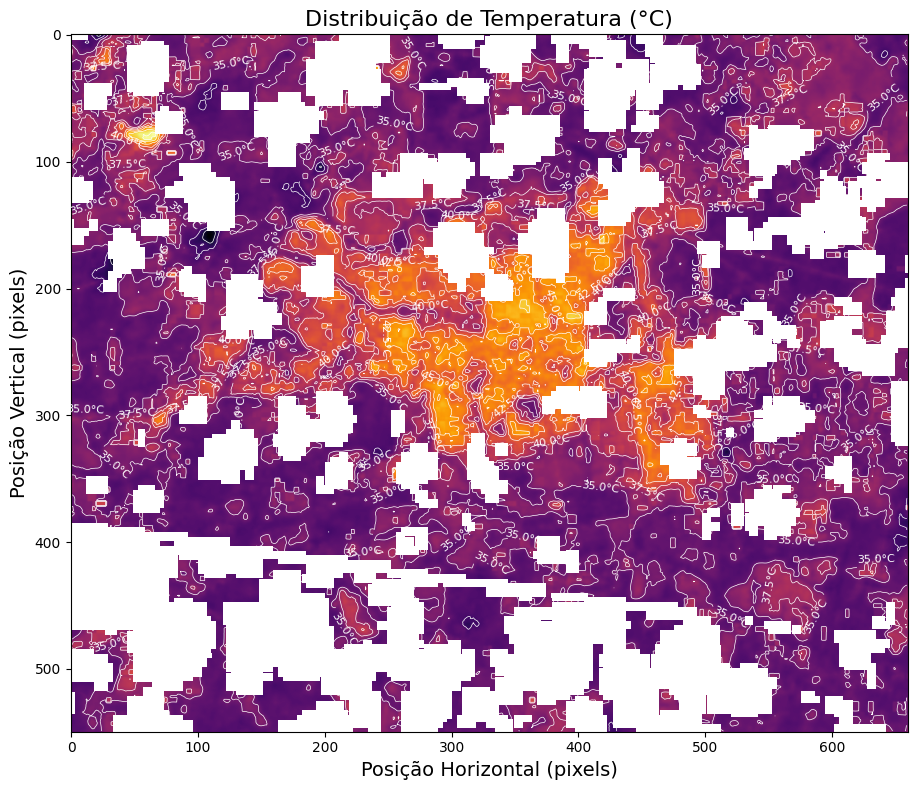

In [ ]:


# Normalizar os valores de temperatura para a barra de cores
vmin = np.min(temp_celcius)  # valor mínimo
vmax = np.max(temp_celcius)  # valor máximo

# Criar a figura com tamanho adequado

plt.figure(figsize=(12, 8))

# Aplicar interpolação e escolher paleta de cores
plt.imshow(temp_celcius, cmap='inferno', interpolation='bicubic', vmin=vmin, vmax=vmax)

# Adicionar contornos para realçar as diferenças de temperatura
contours = plt.contour(temp_celcius, levels=10, colors='white', linewidths=0.5)
plt.clabel(contours, inline=True, fontsize=8, fmt='%1.1f°C')



# Melhorar o título e rótulos dos eixos
plt.title('Distribuição de Temperatura (°C)', fontsize=16)
plt.xlabel('Posição Horizontal (pixels)', fontsize=14)
plt.ylabel('Posição Vertical (pixels)', fontsize=14)

# Mostrar a imagem aprimorada
plt.tight_layout()  # Ajustar layout para evitar sobreposição
plt.show()


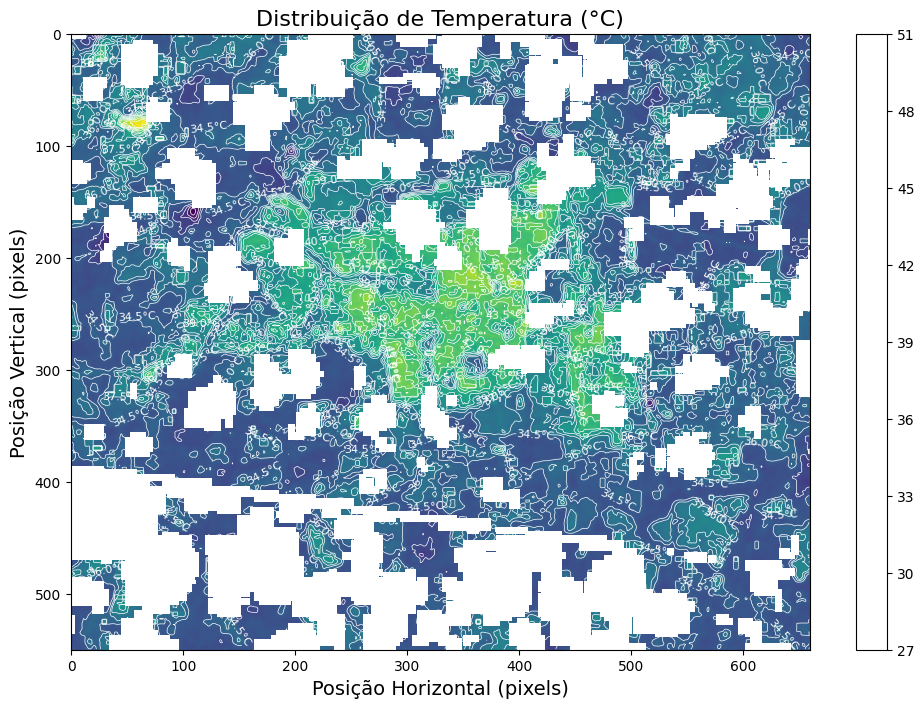

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_temperature_distribution(data, cmap='inferno', levels=10, vmin=None, vmax=None, figsize=(12, 8), savefig=False, filename='temperature_plot.png'):
    """
    Cria um gráfico de calor da distribuição de temperatura.

    Args:
        data: Matriz numpy com os dados de temperatura.
        cmap: Paleta de cores (default: 'inferno').
        levels: Número de níveis de contorno (default: 10).
        vmin: Valor mínimo da escala de cores (default: mínimo dos dados).
        vmax: Valor máximo da escala de cores (default: máximo dos dados).
        figsize: Tamanho da figura em polegadas (default: (12, 8)).
        savefig: Se True, salva a figura (default: False).
        filename: Nome do arquivo para salvar a figura (default: 'temperature_plot.png').
    """

    # Normalizar os valores de temperatura
    if vmin is None:
        vmin = np.min(data)
    if vmax is None:
        vmax = np.max(data)

    # Criar a figura
    plt.figure(figsize=figsize)

    # Plotar a imagem de calor
    plt.imshow(data, cmap=cmap, interpolation='bicubic', vmin=vmin, vmax=vmax)

    # Adicionar contornos
    contours = plt.contour(data, levels=levels, colors='white', linewidths=0.5)
    plt.clabel(contours, inline=True, fontsize=8, fmt='%1.1f°C')

    # Adicionar barra de cores
    plt.colorbar()

    # Melhorar o título e rótulos dos eixos
    plt.title('Distribuição de Temperatura (°C)', fontsize=16)
    plt.xlabel('Posição Horizontal (pixels)', fontsize=14)
    plt.ylabel('Posição Vertical (pixels)', fontsize=14)



    plt.show()

# Exemplo de uso
# Assumindo que 'temp_celcius' é uma matriz numpy com os dados de temperatura
plot_temperature_distribution(temp_celcius, cmap='viridis', levels=15, savefig=True, filename='my_temperature_plot.png')

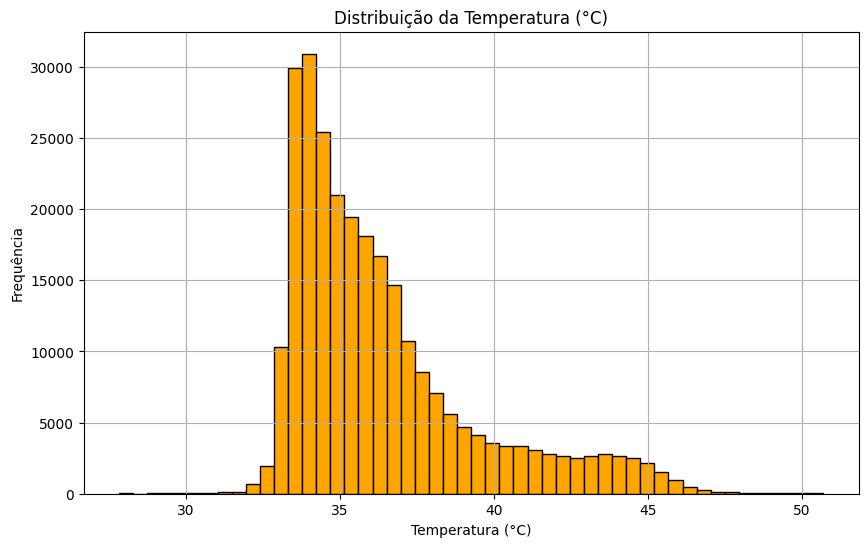

In [ ]:
# Leitura e ajuste dos valores de temperatura
lwir11 = read(items[0].assets['lwir11'].href, bbox=bbox)
scaled_lwir11 = (lwir11 * 0.00341802) + 149
temp_celcius = scaled_lwir11 - 273

# Criando um gráfico de histograma para visualizar a distribuição das temperaturas
plt.figure(figsize=(10, 6))
plt.hist(temp_celcius.flatten(), bins=50, color='orange', edgecolor='black')
plt.title('Distribuição da Temperatura (°C)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

In [ ]:
red = read(item.assets['red'].href, bbox=bbox)

In [ ]:
nir = read(item.assets['nir08'].href, bbox=bbox)

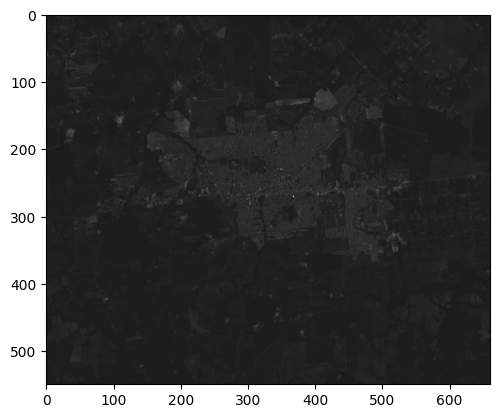

In [ ]:
plt.imshow(red, cmap='gray');

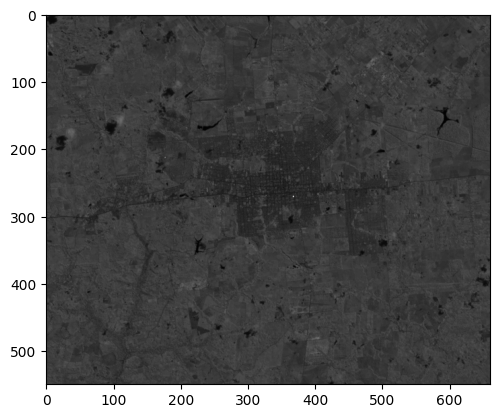

In [ ]:
plt.imshow(nir, cmap='gray');

In [ ]:
n_red = normalize(red)
n_nir = normalize(nir)

In [ ]:
np.seterr(divide='ignore', invalid='ignore')
ndvi = (n_nir - n_red) / (n_nir + n_red)
ndvi = np.nan_to_num(ndvi, nan=0.0, posinf=0.0, neginf=0.0)

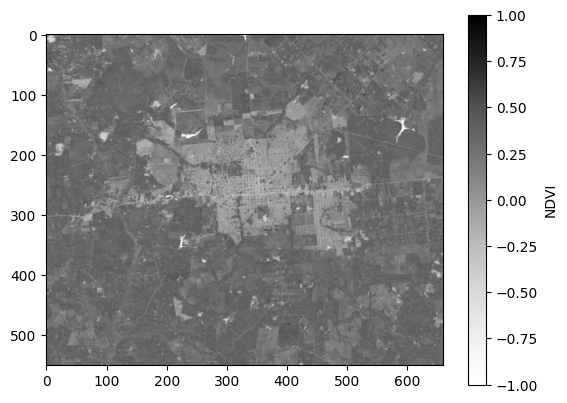

In [ ]:
plt.imshow(ndvi, cmap='Greys')
plt.colorbar(label='NDVI')

In [ ]:
emissividade = 0.004 * ndvi + 0.996
print(emissividade)

[[0.9974195861587308 0.9974854728927034 0.9974632173093759 ...
  0.9973196575527338 0.9972653739326625 0.9973896032719276]
 [0.9974220683109064 0.997566606506833 0.9975132916265262 ...
  0.9972288837398654 0.9971237900656377 0.9974088844937391]
 [0.9974852963569373 0.9975892962084582 0.9975461371486752 ...
  0.9973304614738792 0.9972795612445149 0.997458584352698]
 ...
 [0.9975172975889968 0.997508152838081 0.9975381209440157 ...
  0.9972832079235256 0.9973037673284975 0.9975038146108359]
 [0.9975217398500137 0.9975074924536714 0.9975106293190168 ...
  0.9971199151712637 0.9972684784349619 0.9973544961096554]
 [0.9974854757693016 0.9975308220487484 0.9975389500282177 ...
  0.9966073668051301 0.9971885365023415 0.9973091895985468]]


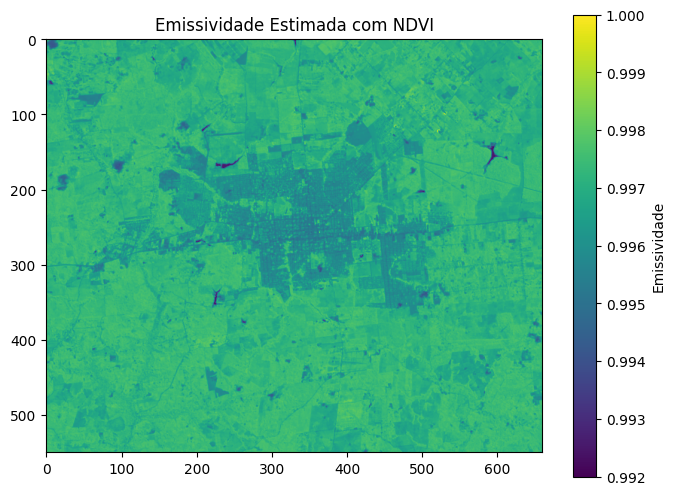

In [ ]:
# Visualização da emissividade
plt.figure(figsize=(8, 6))
plt.imshow(emissividade, cmap='viridis')
plt.colorbar(label='Emissividade')
plt.title('Emissividade Estimada com NDVI')
plt.show()

In [ ]:
st_emis = read(item.assets['st_emis'].href, bbox=bbox)

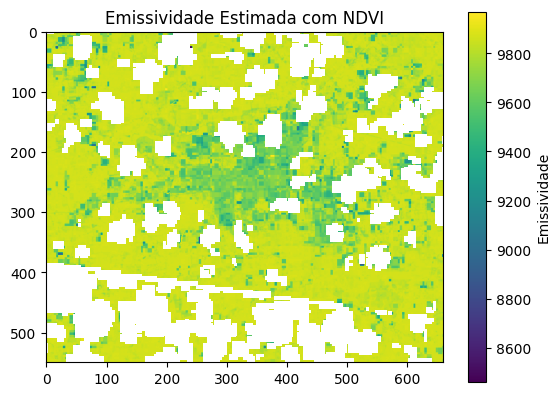

In [ ]:
emissividade2 = st_emis

plt.imshow(emissividade2, cmap='viridis')
plt.colorbar(label='Emissividade')
plt.title('Emissividade Estimada com NDVI')
plt.show()

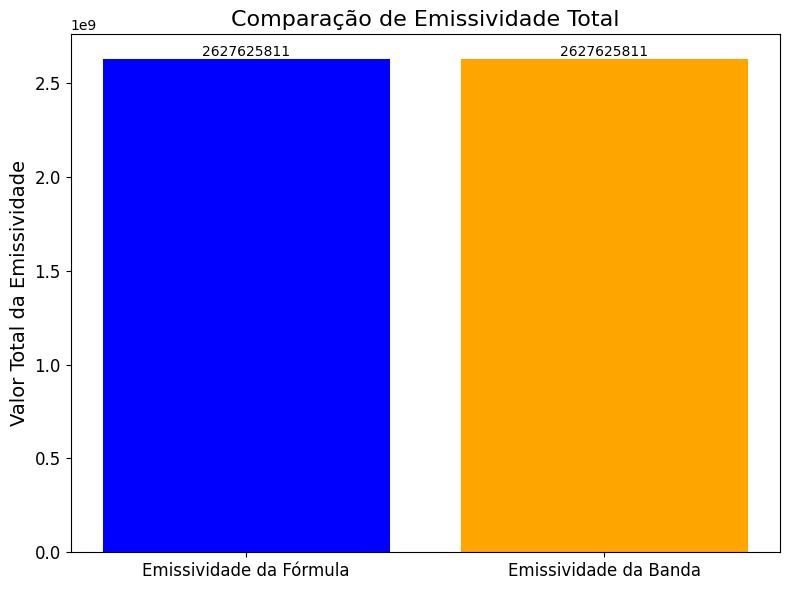

In [ ]:
# Supondo que emissividade e emissividade2 sejam 2D
# Calculando o valor total (soma) para cada emissividade
total_emissividade = emissividade.sum()
total_emissividade2 = emissividade2.sum()

# Criando os dados para o gráfico de barras
labels = ['Emissividade da Fórmula', 'Emissividade da Banda']
totais = [total_emissividade, total_emissividade2]

# Criando o gráfico de barras
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, totais, color=['blue', 'orange'])

# Configurações do gráfico
plt.ylabel('Valor Total da Emissividade', fontsize=14)
plt.title('Comparação de Emissividade Total', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adicionando rótulos de valor nas barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom', ha='center')

plt.tight_layout()  # Ajusta o layout
plt.show()

In [ ]:
print(emissividade)


[[9862 -- -- ... 9857 9868 9869]
 [9862 -- -- ... 9853 9865 9869]
 [9866 -- -- ... 9871 9864 9866]
 ...
 [9872 9871 9871 ... 9866 9869 9714]
 [9872 9871 9870 ... 9863 9866 9714]
 [9871 9871 9871 ... 9852 9862 9714]]


In [ ]:
print(emissividade2)

[[9862 -- -- ... 9857 9868 9869]
 [9862 -- -- ... 9853 9865 9869]
 [9866 -- -- ... 9871 9864 9866]
 ...
 [9872 9871 9871 ... 9866 9869 9714]
 [9872 9871 9870 ... 9863 9866 9714]
 [9871 9871 9871 ... 9852 9862 9714]]


In [ ]:
mtl.txt = read(item.assets['mtl.txt'].href, bbox=bbox)

RasterioIOError: '/vsicurl/https://data.inpe.br/bdc/data/landsat/v2/223/061/2022/LC08_L2SP_223061_20220720_20220726_02_T1/LC08_L2SP_223061_20220720_20220726_02_T1_MTL.txt' not recognized as being in a supported file format.

In [ ]:
list[mtl.txt]